# LoRa Chirp Modulation: Math, Symbols, and Visualizations

This notebook is an introduction to the chirp spread spectrum (CSS) physical layer used by LoRa. It follows the signal-processing view in *Frequency Shift Chirp Modulation: The LoRa Modulation* (Vangelista and Elzanaty, 2017).

By the end, you will be able to:

- generate a discrete baseband LoRa-like up-chirp;
- encode a symbol as a cyclic chirp shift;
- recover that symbol by dechirping and taking an FFT;
- see why spreading factor (SF) trades bit rate for long symbol duration; and
- distinguish a LoRa FFT-bin decision from a Wi-Fi QAM constellation decision.

> This is a pedagogical, baseband model. Real LoRa packet formatting adds preambles, sync words, headers, whitening, interleaving, FEC, CRC, synchronization, and hardware impairments.

### Where LoRa helps an IoT/UAV mission

Small, infrequent sensor reports are a good fit: a node can sleep between transmissions, while a UAV brings a receiver closer to otherwise hard-to-reach sensors. Longer chirps let the receiver integrate weak signals; a constant-envelope waveform permits an efficient RF power amplifier. These benefits trade against airtime, capacity, and latency.

| Task | LoRa contribution | Cost to inspect |
|---|---|---|
| Soil, water, or equipment readings | Small reports over a high-link-budget radio | Duty cycle, retries, and node battery energy |
| UAV collecting from remote nodes | Elevated/mobile receiver can reduce blockage and distance | Contact time, antenna nulls, Doppler, and onboard EMI |
| Video, images, or bulk logs | LoRa can carry a status message or transfer request | Use a higher-rate link for bulk data |

**Keep frequency and modulation separate.** Notebooks 0-6 use 2.44 GHz / 812.5 kHz; 7 and 9 use the proposed 923 MHz field profile. At equal range and antenna gains, 923 MHz has about 8.4 dB less free-space loss than 2.44 GHz; that is a carrier-frequency advantage, not a CSS gain. Comparing LoRa to Wi-Fi at the same carrier removes that difference. Narrow bandwidth lowers integrated noise, but also lowers rate. Long airtime can erase a low-power radio's energy advantage.

LoRa is the PHY; packet schedules and LoRaWAN are higher-layer choices. The scheduled collection in Notebook 9 is a custom LoRa experiment, not a complete LoRaWAN implementation. SF7-SF12 is this series' teaching range, not a universal modem limit; supported SF/BW combinations depend on the radio.

## 1. The core quantities

For spreading factor $SF$, a LoRa symbol has $M=2^{SF}$ possible cyclic shifts. The chip rate is approximately the selected bandwidth $BW$, so:

$$T_s = \frac{2^{SF}}{BW}, \qquad R_s = \frac{BW}{2^{SF}}$$

A symbol selects one of $M$ values, so it represents $SF=\log_2 M$ raw bits. With FEC coding rate $R_c$, an approximate PHY bit rate is:

$$R_b \approx SF \cdot R_s \cdot R_c.$$

This excludes packet overhead. The RF center frequency $f_c$ determines wavelength, $\lambda=c/f_c$; bandwidth and SF determine the waveform timing.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": 0.25})

C = 299_792_458.0
FC_HZ = 2.44e9
BW_HZ = 812_500.0  # One useful 2.4 GHz LoRa bandwidth; change to explore.
CODING_RATE = 4 / 5

print(f"Carrier wavelength at {FC_HZ / 1e9:.2f} GHz: {C / FC_HZ * 100:.2f} cm")
print(f"Selected LoRa bandwidth: {BW_HZ / 1e3:.1f} kHz")

Carrier wavelength at 2.44 GHz: 12.29 cm
Selected LoRa bandwidth: 812.5 kHz


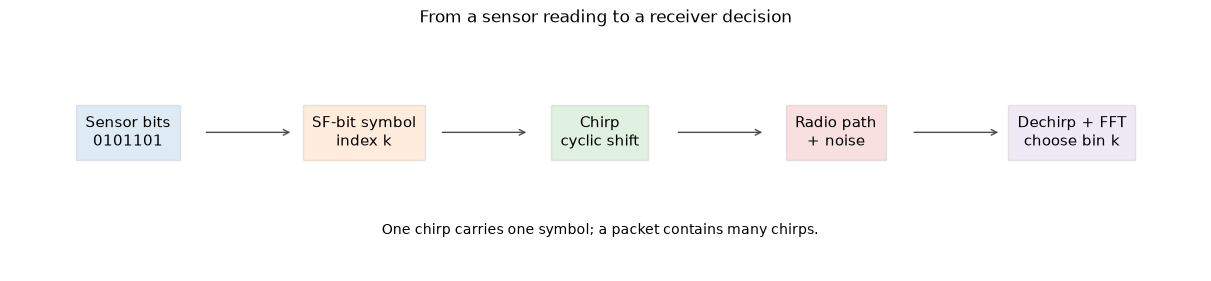

In [2]:
# Signal-flow schematic: each arrow is one transformation, not another radio.
fig, ax = plt.subplots(figsize=(12, 2.7), constrained_layout=True)
labels = ['Sensor bits\n0101101', 'SF-bit symbol\nindex k', 'Chirp\ncyclic shift', 'Radio path\n+ noise', 'Dechirp + FFT\nchoose bin k']
for i, label in enumerate(labels):
    ax.text(i, 0.5, label, ha='center', va='center', fontsize=11,
            bbox=dict(boxstyle='square,pad=0.6', fc=f'C{i}', alpha=0.14, ec='0.4'))
    if i:
        ax.annotate('', xy=(i - 0.30, 0.5), xytext=(i - 0.68, 0.5), arrowprops=dict(arrowstyle='->', color='0.3'))
ax.text(2, -0.05, 'One chirp carries one symbol; a packet contains many chirps.', ha='center')
ax.set(xlim=(-0.5, 4.55), ylim=(-0.25, 1.05), title='From a sensor reading to a receiver decision')
ax.axis('off')
plt.show()

In [3]:
def lora_parameters(sf, bw_hz=BW_HZ, coding_rate=CODING_RATE):
    """Return the idealized timing and raw-rate quantities for one LoRa SF."""
    m = 1 << sf
    symbol_time_s = m / bw_hz
    symbol_rate = 1 / symbol_time_s
    return {
        "sf": sf,
        "M": m,
        "symbol_time_s": symbol_time_s,
        "symbol_rate": symbol_rate,
        "raw_bits_per_symbol": sf,
        "coded_bit_rate_bps": sf * symbol_rate * coding_rate,
        "ideal_processing_gain_db": 10 * np.log10(m),
    }

rows = [lora_parameters(sf) for sf in range(7, 13)]
print(" SF | M symbols | symbol time | rate with CR=4/5 | ideal 10log10(M)")
print("----|-----------|-------------|------------------|------------------")
for row in rows:
    print(
        f" {row['sf']:>2} | {row['M']:>9,} | {row['symbol_time_s'] * 1e3:>9.3f} ms | "
        f"{row['coded_bit_rate_bps']:>13,.0f} bit/s | {row['ideal_processing_gain_db']:>14.1f} dB"
    )

 SF | M symbols | symbol time | rate with CR=4/5 | ideal 10log10(M)
----|-----------|-------------|------------------|------------------
  7 |       128 |     0.158 ms |        35,547 bit/s |           21.1 dB
  8 |       256 |     0.315 ms |        20,312 bit/s |           24.1 dB
  9 |       512 |     0.630 ms |        11,426 bit/s |           27.1 dB
 10 |     1,024 |     1.260 ms |         6,348 bit/s |           30.1 dB
 11 |     2,048 |     2.521 ms |         3,491 bit/s |           33.1 dB
 12 |     4,096 |     5.041 ms |         1,904 bit/s |           36.1 dB


## 2. A discrete baseband chirp

We use one complex sample per chip. For $n=0,\ldots,M-1$, the reference up-chirp is:

$$u[n] = \exp\left(j2\pi\left(\frac{n^2}{2M}-\frac{n}{2}\right)\right).$$

Its phase is quadratic, so its instantaneous frequency increases linearly. The $-n/2$ term simply centers the sweep around baseband zero. Sign and shift conventions differ between derivations; this notebook uses a convention in which the detected FFT-bin index equals the transmitted symbol.

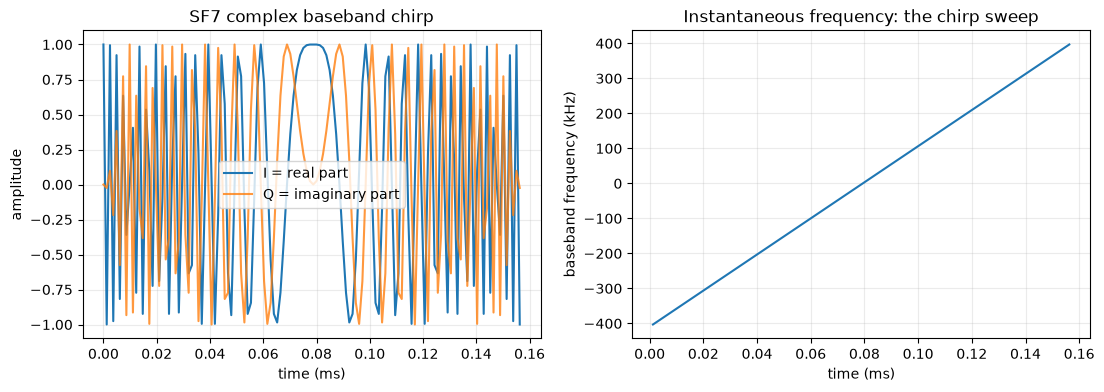

In [4]:
def reference_upchirp(sf):
    """Unit-amplitude, discrete baseband up-chirp with M=2**sf samples."""
    m = 1 << sf
    n = np.arange(m)
    return np.exp(1j * 2 * np.pi * (n**2 / (2 * m) - n / 2))


def lora_symbol(symbol, sf):
    """Encode symbol in [0, 2**sf) as a cyclic shift of the reference chirp."""
    m = 1 << sf
    if not 0 <= symbol < m:
        raise ValueError(f"symbol must be in [0, {m})")
    return np.roll(reference_upchirp(sf), -symbol)


def instantaneous_frequency_hz(samples, sample_rate_hz):
    """Estimate frequency from sample-to-sample phase changes."""
    phase_step = np.angle(samples[1:] * np.conj(samples[:-1]))
    return phase_step * sample_rate_hz / (2 * np.pi)

sf = 7
chirp = reference_upchirp(sf)
time_ms = np.arange(chirp.size) / BW_HZ * 1e3

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(time_ms, chirp.real, label="I = real part")
axes[0].plot(time_ms, chirp.imag, label="Q = imaginary part", alpha=0.8)
axes[0].set(title=f"SF{sf} complex baseband chirp", xlabel="time (ms)", ylabel="amplitude")
axes[0].legend()

freq_khz = instantaneous_frequency_hz(chirp, BW_HZ) / 1e3
axes[1].plot(time_ms[1:], freq_khz)
axes[1].set(title="Instantaneous frequency: the chirp sweep", xlabel="time (ms)", ylabel="baseband frequency (kHz)")
plt.show()

## 3. A LoRa symbol is a cyclic shift

The symbol $m\in\{0,\ldots,M-1\}$ is represented by a cyclic shift of the same chirp. On a time-frequency plot it looks like the same diagonal sweep, with the wrap-around at a different place.

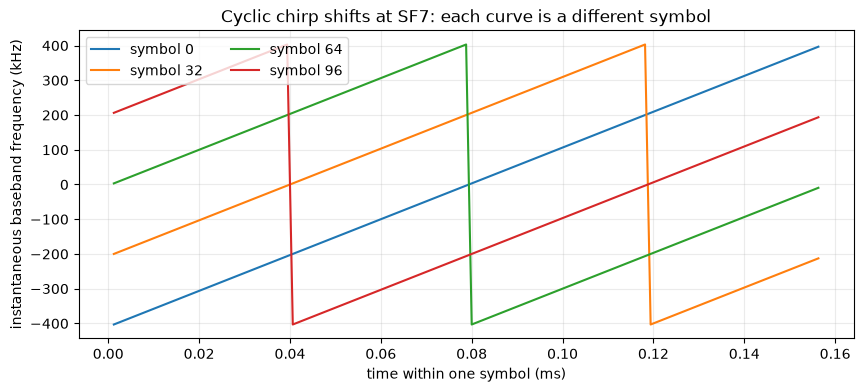

In [5]:
sf = 7
m = 1 << sf
symbols = [0, m // 4, m // 2, 3 * m // 4]
time_ms = np.arange(m) / BW_HZ * 1e3

fig, ax = plt.subplots(figsize=(10, 4))
for symbol in symbols:
    waveform = lora_symbol(symbol, sf)
    f_khz = instantaneous_frequency_hz(waveform, BW_HZ) / 1e3
    ax.plot(time_ms[1:], f_khz, label=f"symbol {symbol}")

ax.set(
    title=f"Cyclic chirp shifts at SF{sf}: each curve is a different symbol",
    xlabel="time within one symbol (ms)",
    ylabel="instantaneous baseband frequency (kHz)",
)
ax.legend(ncol=2)
plt.show()

## 4. Dechirping turns the chosen shift into one FFT bin

The receiver multiplies the received chirp by the conjugate of the reference up-chirp. This removes the sweep. An ideal transmitted symbol then becomes a complex tone, and the $M$-point FFT has one dominant bin:

$$y_m[n] = x_m[n]u^*[n] \quad\Longrightarrow\quad Y_m[k]\text{ peaks at }k=m.$$

That one-hot FFT-bin decision is the practical visual analogue of a LoRa constellation.

In [6]:
def dechirp_fft(samples, sf):
    """Dechirp one symbol and return its M-point FFT."""
    return np.fft.fft(samples * np.conj(reference_upchirp(sf)))


def detect_symbol(samples, sf):
    """Maximum-bin detector for the convention used in this notebook."""
    return int(np.argmax(np.abs(dechirp_fft(samples, sf))))


# Small runnable correctness check: cyclic-shift encoding must round-trip through detection.
for sf in (7, 12):
    m = 1 << sf
    for symbol in (0, 1, m // 2, m - 1):
        waveform = lora_symbol(symbol, sf)
        assert np.allclose(np.abs(waveform), 1.0)
        assert detect_symbol(waveform, sf) == symbol

print("Round-trip checks passed for SF7 and SF12.")

Round-trip checks passed for SF7 and SF12.


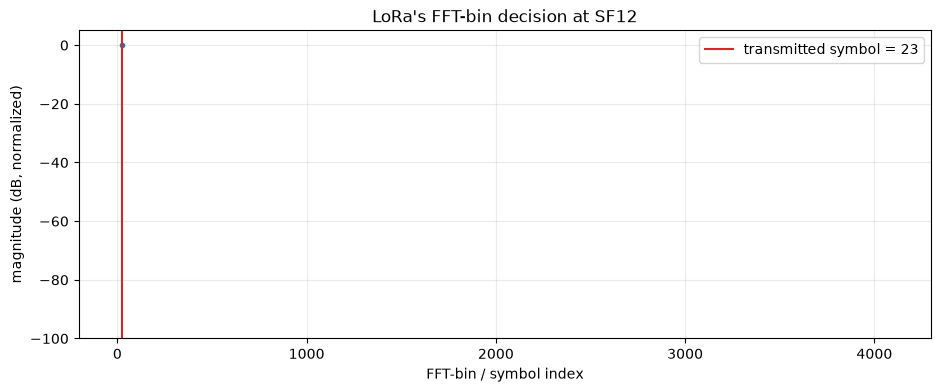

In [7]:
sf = 12
transmitted_symbol = 23
spectrum = dechirp_fft(lora_symbol(transmitted_symbol, sf), sf)
power_db = 20 * np.log10(np.maximum(np.abs(spectrum) / spectrum.size, 1e-12))

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(power_db, marker=".", linestyle="none")
ax.axvline(transmitted_symbol, color="tab:red", label=f"transmitted symbol = {transmitted_symbol}")
ax.set(
    title=f"LoRa's FFT-bin decision at SF{sf}",
    xlabel="FFT-bin / symbol index",
    ylabel="magnitude (dB, normalized)",
    ylim=(-100, 5),
)
ax.legend()
plt.show()

## 5. A noisy symbol

The detector does not need a QAM point to remain close to a fixed coordinate. It needs the desired FFT bin to remain stronger than the alternatives after dechirping. The SNR below is sample SNR for this toy complex-AWGN model, not a complete receiver-sensitivity measurement.

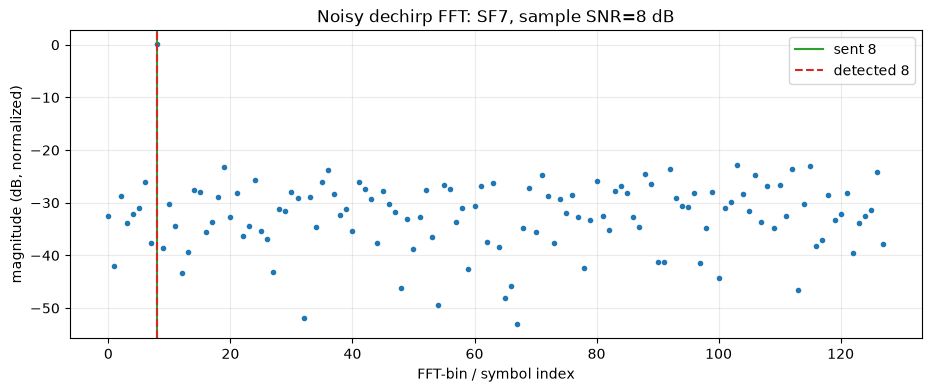

In [8]:
def add_awgn(samples, snr_db, rng):
    """Add complex white Gaussian noise at a requested sample SNR."""
    signal_power = np.mean(np.abs(samples) ** 2)
    noise_power = signal_power / (10 ** (snr_db / 10))
    noise = np.sqrt(noise_power / 2) * (rng.standard_normal(samples.size) + 1j * rng.standard_normal(samples.size))
    return samples + noise

sf = 7
symbol = 8
snr_db = 8
rng = np.random.default_rng(42)
received = add_awgn(lora_symbol(symbol, sf), snr_db, rng)
spectrum = dechirp_fft(received, sf)
detected = detect_symbol(received, sf)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(20 * np.log10(np.maximum(np.abs(spectrum) / spectrum.size, 1e-12)), marker=".", linestyle="none")
ax.axvline(symbol, color="tab:green", label=f"sent {symbol}")
ax.axvline(detected, color="tab:red", linestyle="--", label=f"detected {detected}")
ax.set(title=f"Noisy dechirp FFT: SF{sf}, sample SNR={snr_db} dB", xlabel="FFT-bin / symbol index", ylabel="magnitude (dB, normalized)")
ax.legend()
plt.show()

## 6. SF, bandwidth, and wavelength are different levers

- **Center frequency** $f_c$ sets wavelength and therefore antenna scale, free-space loss, and Doppler. At 2.44 GHz, $\lambda\approx12.29$ cm.
- **Bandwidth** $BW$ is the fixed frequency span of the chirp. A chirp centered at 2.44 GHz with $BW=812.5$ kHz sweeps approximately 2.43959375 to 2.44040625 GHz. It does not change bandwidth while transmitting.
- **Spreading factor** determines how many chips fit in one symbol and therefore symbol time. Increasing SF by one doubles $T_s$.

Wi-Fi OFDM uses its bandwidth as many simultaneous, narrow QAM subcarriers. LoRa CSS uses one cyclic chirp that traverses its allocated bandwidth over one symbol.

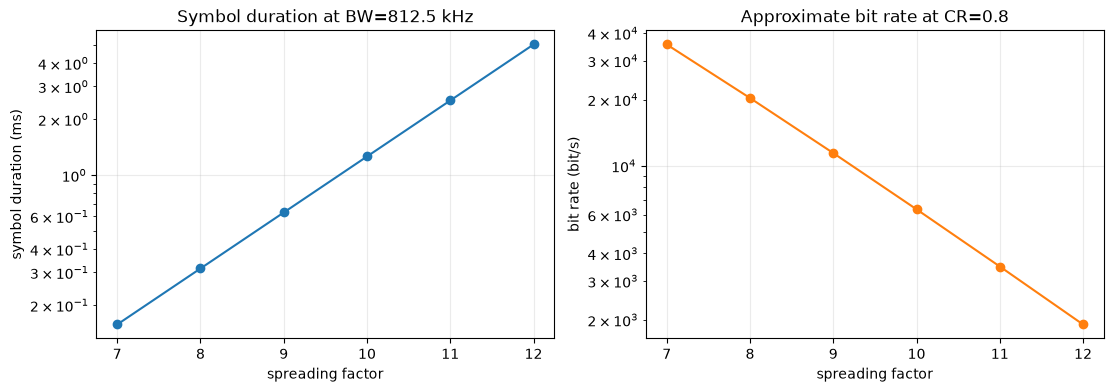

In [9]:
sf_values = np.arange(7, 13)
symbol_times_ms = np.array([lora_parameters(sf)["symbol_time_s"] for sf in sf_values]) * 1e3
bit_rates = np.array([lora_parameters(sf)["coded_bit_rate_bps"] for sf in sf_values])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].semilogy(sf_values, symbol_times_ms, marker="o")
axes[0].set(title=f"Symbol duration at BW={BW_HZ / 1e3:.1f} kHz", xlabel="spreading factor", ylabel="symbol duration (ms)", xticks=sf_values)

axes[1].semilogy(sf_values, bit_rates, marker="o", color="tab:orange")
axes[1].set(title=f"Approximate bit rate at CR={CODING_RATE:g}", xlabel="spreading factor", ylabel="bit rate (bit/s)", xticks=sf_values)
plt.show()

## 7. Follow-up tutorials

This series now progresses from an inspectable CSS waveform toward the planned ground-to-UAV experiment. Completed notebooks are marked below; later notebooks keep propagation, hardware interference, and link adaptation separate so each result has a clear cause:

1. **LoRa packet PHY (complete)**: framing, whitening, teaching FEC, interleaving, CRC, and airtime. Notebook 1 is conceptual rather than a bit-exact Semtech implementation.
2. **AWGN error curves (complete)**: Monte-Carlo symbol and packet reliability for ideal chirps across SF7-SF12.
3. **Multipath and Doppler (complete)**: a hand-selected time-varying channel applied with Sionna PHY, isolating delay and uncompensated motion effects.
4. **Ground-to-UAV geometry and Sionna RT (complete)**: one stationary ground transmitter and one fixed-altitude UAV receiver; animate the route and connect range, elevation, radial speed, Doppler, antenna pattern, and free-space path gain.
5. **Propagation scene and installation effects (controlled first version complete)**: add flat-ground reflection, ITU material uncertainty, UAV dipole attitude, and an explicit placeholder for measured airframe shadowing. Terrain, buildings, and calibrated installed patterns remain field-site extensions.
6. **Interference and receiver impairments (complete)**: compare co-SF and cross-SF LoRa traffic, an effective post-filter Wi-Fi residue, residual oscillator error, and measured motor/ESC receiver desensitization. EMI is not supplied automatically by ray tracing.
7. **Packet reliability and flight-aware adaptation (complete teaching abstraction)**: choose SF, bandwidth, coding rate, and transmit power from transparent link-margin and packet-error surrogates, airtime, retries, and mission-time constraints. Calibration against measured packet curves remains a field-work extension.
8. **CSS waveform variants (complete teaching comparison)**: compare baseline LoRa-like CSS with chirp-rate indexing and a two-tone index-modulated waveform in spectral efficiency, PAPR, detector work, and AWGN error rate. The variants are research waveforms, not interoperable LoRa.
9. **Multiuser collection (controlled first version complete)**: simulate four ground transmitters, deterministic packet schedules, collision and capture handling, and one moving UAV receiver that preserves per-packet records along its route.

## Focused references

- L. Vangelista, [Frequency Shift Chirp Modulation: The LoRa Modulation](https://doi.org/10.1109/LSP.2017.2762960), IEEE Signal Processing Letters, 2017. Read for the frequency-shift model and dechirp/FFT detector.
- A. Maleki et al., [A Tutorial on Chirp Spread Spectrum for LoRaWAN: Basics and Key Advances](https://arxiv.org/abs/2310.10503). Read for signal generation, error performance, synchronization, and practical limits.
- Semtech, [LoRa PHY overview](https://www.semtech.com/lora/what-is-lora) and [radio-family comparison](https://www.semtech.com/products/wireless-rf/end-nodes-ics). Check the actual device's frequency, SF, bandwidth, and current specifications.